In [1]:
import torch
import matplotlib.pyplot as plt
from torch.optim import Adam
from pipeline import forward, get_latent_mean_std, get_latent_from_text

/usr/local/Caskroom/miniconda/base/envs/nphm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
lat_rep = torch.load("optim_latent").requires_grad_(True)

In [ ]:
lat_mean, lat_std = get_latent_mean_std()
lat_rep = (torch.randn(lat_mean.shape) * lat_std * 0.85 + lat_mean).detach().requires_grad_(True)

In [11]:
optimizer = Adam(params=[lat_rep],
                 lr=0.001, 
                 maximize=True)

In [13]:
res = 250
render_config = {
    "pu": res,
    "pv": res,
    "camera_distance": 2.,
    "camera_angle": 0.,
    "ambient_coeff": 0.1,
    "diffuse_coeff": 0.6,
    "specular_coeff": 0.3,
    "shininess": 32.,
    "focal_length": 3.
}

In [14]:
score = forward(lat_rep, "untextured render of a man with long hair and an open mouth", render_config)

In [ ]:
score[0].backward()

In [ ]:
#plt.imshow(score[1].detach().numpy())

In [3]:
latent, hist = get_latent_from_text("untextured render of a woamn with long straight hair and an open mouth",init_lat=lat_rep, n_updates=5)

/usr/local/Caskroom/miniconda/base/envs/nphm/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3191.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


update step 0 - score: tensor([[32.2465]], grad_fn=<MmBackward0>)
update step 1 - score: tensor([[32.7523]], grad_fn=<MmBackward0>)
update step 2 - score: tensor([[32.6016]], grad_fn=<MmBackward0>)
update step 3 - score: tensor([[33.2355]], grad_fn=<MmBackward0>)
update step 4 - score: tensor([[33.6557]], grad_fn=<MmBackward0>)


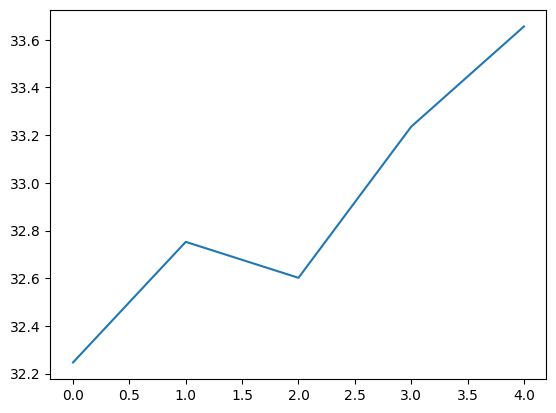

In [4]:
plt.plot(torch.tensor(hist["scores"]).numpy())

In [5]:
torch.save(latent, "optim_latent")

In [6]:
torch.save(torch.stack(hist["latents"]), "latent_history")

In [7]:
torch.save(torch.stack(hist["images"]), "render_history")

In [ ]:
plt.imshow(hist["images"][3].detach().numpy())
plt.axis('off')  # Turn off axes
plt.show()
#plt.savefig(f"optim_img/high_lr_{i}", bbox_inches='tight')

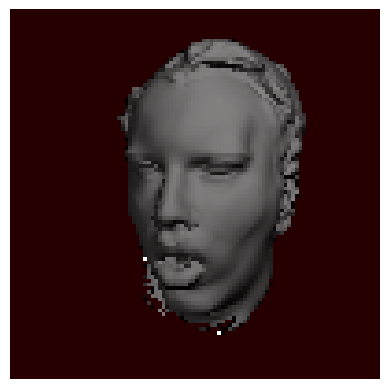

In [8]:
for i, im in enumerate(hist["images"]):
    plt.imshow(im.detach().numpy())
    plt.axis('off')  # Turn off axes
    #plt.show()
    plt.savefig(f"optim_img/high_lr_{5+i}", bbox_inches='tight')